**Introducción a la Ciencia de Datos 2026**  
Posgrado en Ciencias de la Computación - CICESE  
M.C. Joan Manuel Raygoza Romero

# ICD - 7: Ingeniería de características

Sesión 7 del curso. Diapositivas: [icd-07-ingenieria.pdf](https://github.com/husseinlopez/icd2026/blob/main/clases/icd-07-ingenieria.pdf)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/husseinlopez/icd2026/blob/main/icd-07-ingenieria.ipynb)

1. Preparación y datos.
2. Texto: BoW, n-gramas y TF-IDF.
3. Imágenes: histogramas y LBP.
4. Audio: espectrograma, escala Mel y MFCC.
5. Integración y buenas prácticas.

Ejecuta las celdas en orden. Los textos y sonidos se generan aquí; las fotografías vienen incluidas en scikit-learn. No se descargan conjuntos de datos externos.

## 1. Preparación
Si falta alguna biblioteca, descomenta y ejecuta la siguiente celda. La instalación requiere internet; los ejemplos no. En Jupyter, reinicia el kernel si lo solicita el entorno.

In [1]:
# %pip install numpy pandas matplotlib scipy scikit-learn scikit-image librosa pillow

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Audio
from sklearn.datasets import load_sample_image
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from skimage import color, feature, measure, util
from PIL import Image
import librosa
import librosa.display
from scipy.fft import dct

rng = np.random.default_rng(42)
plt.rcParams.update({'figure.figsize': (9, 4), 'font.size': 10})

### 1.1 Datos utilizados

| Datos | Procedencia | Unidad de observación | Uso |
|---|---|---|---|
| Corpus de frases en español | Ejemplos didácticos definidos aquí | Documento | BoW, n-gramas y TF-IDF |
| `china.jpg` y `flower.jpg` | Fotografías distribuidas con scikit-learn | Imagen RGB | Color, LBP y HOG |
| Máscara asimétrica | Generada con NumPy | Objeto binario | Momentos de Hu |
| Tono, barrido y mezcla | Señales sintéticas generadas con NumPy | Grabación de 2 segundos | Espectrograma y MFCC |

Las señales sintéticas permiten conocer sus frecuencias de antemano; no representan grabaciones reales ni resultados de clasificación.

## 2. Texto
### 2.1 Documentos y tokenización
Cada fila será un documento. Conservamos las palabras «el» y «no» para observar el orden y la negación. `CountVectorizer` convierte a minúsculas y tokeniza palabras de al menos dos caracteres por defecto.

Los documentos de prueba se reservan desde el inicio: no deben intervenir en el vocabulario ni en el IDF.

In [3]:
textos_train = [
    'gato negro',
    'gato blanco',
    'perro negro negro',
    'el perro persigue al gato',
    'el gato persigue al perro',
    'el servicio funciona',
    'el servicio no funciona',
]
textos_test = ['el servicio funciona rápido', 'gato naranja']
nombres_doc = [f'd{i+1}' for i in range(len(textos_train))]
display(pd.DataFrame({'documento': nombres_doc, 'texto': textos_train}))
analizador = CountVectorizer().build_analyzer()
print('Tokens:', analizador(textos_train[-1]))

,documento,texto
0,d1,gato negro
1,d2,gato blanco
2,d3,perro negro negro
3,d4,el perro persigue al gato
4,d5,el gato persigue al perro
5,d6,el servicio funciona
6,d7,el servicio no funciona


Tokens: ['el', 'servicio', 'no', 'funciona']


### 2.2 Bag of Words: matriz de conteos
`fit_transform` aprende el vocabulario del entrenamiento y construye una matriz dispersa. Cada columna corresponde a un término.

$$x_j = \operatorname{conteo}(t_j,d)$$

Convertimos a una matriz densa solo porque este ejemplo es pequeño.

In [4]:
bow = CountVectorizer()
X_bow = bow.fit_transform(textos_train)
terminos = bow.get_feature_names_out()
tabla_bow = pd.DataFrame(X_bow.toarray(), index=nombres_doc, columns=terminos)
display(tabla_bow)
print('Forma (documentos, términos):', X_bow.shape)
print('Proporción de ceros:', round(1 - X_bow.nnz / np.prod(X_bow.shape), 3))
print('¿d4 y d5 tienen el mismo BoW?', np.array_equal(X_bow.toarray()[3], X_bow.toarray()[4]))

,al,blanco,el,funciona,gato,negro,no,perro,persigue,servicio
d1,0,0,0,0,1,1,0,0,0,0
d2,0,1,0,0,1,0,0,0,0,0
d3,0,0,0,0,0,2,0,1,0,0
d4,1,0,1,0,1,0,0,1,1,0
d5,1,0,1,0,1,0,0,1,1,0
d6,0,0,1,1,0,0,0,0,0,1
d7,0,0,1,1,0,0,1,0,0,1


Forma (documentos, términos): (7, 10)
Proporción de ceros: 0.671
¿d4 y d5 tienen el mismo BoW? True


### 2.3 Presencia y frecuencia relativa
La presencia indica si un término aparece. La frecuencia relativa divide entre la suma de conteos del documento.

$$f_j = \frac{x_j}{\sum_k x_k}$$

**Observa:** d3 contiene dos apariciones de «negro». En la representación binaria esta repetición desaparece.

In [5]:
conteos = X_bow.toarray()
binario = (conteos > 0).astype(int)
relativo = conteos / np.maximum(conteos.sum(axis=1, keepdims=True), 1)
display(pd.DataFrame(
    [conteos[2], binario[2], relativo[2]],
    index=['Conteo d3', 'Presencia d3', 'Frecuencia relativa d3'], columns=terminos
).round(3))

,al,blanco,el,funciona,gato,negro,no,perro,persigue,servicio
Conteo d3,0.0,0.0,0.0,0.0,0.0,2.000,0.0,1.000,0.0,0.0
Presencia d3,0.0,0.0,0.0,0.0,0.0,1.000,0.0,1.000,0.0,0.0
Frecuencia relativa d3,0.0,0.0,0.0,0.0,0.0,0.667,0.0,0.333,0.0,0.0


### 2.4 N-gramas de palabras
`ngram_range=(1, 2)` incluye unigramas y bigramas. Los n-gramas son las unidades; sus pesos pueden ser conteos o TF-IDF.

Comparamos dos frases con los mismos unigramas pero diferente orden, y dos con distinta negación.

In [6]:
ngramas = CountVectorizer(ngram_range=(1, 2))
X_ngramas = ngramas.fit_transform(textos_train)
terms_ng = ngramas.get_feature_names_out()
columnas = ['perro persigue', 'gato persigue', 'servicio funciona', 'no funciona']
tabla_ng = pd.DataFrame(X_ngramas.toarray(), index=nombres_doc, columns=terms_ng)
display(tabla_ng.loc[['d4', 'd5', 'd6', 'd7'], columnas])
print('Dimensión BoW:', X_bow.shape[1], '| Unigramas + bigramas:', X_ngramas.shape[1])
print('Trigramas:', CountVectorizer(ngram_range=(3, 3)).build_analyzer()('el modelo aprende patrones'))

,perro persigue,gato persigue,servicio funciona,no funciona
d4,1,0,0,0
d5,0,1,0,0
d6,0,0,1,0
d7,0,0,0,1


Dimensión BoW: 10 | Unigramas + bigramas: 25
Trigramas: ['el modelo aprende', 'modelo aprende patrones']


### 2.5 N-gramas de caracteres
Con `analyzer='char'` las unidades son caracteres. Aplicamos trigramas a una palabra para reproducir el ejemplo de la presentación.

In [7]:
char_vec = CountVectorizer(analyzer='char', ngram_range=(3, 3))
X_char = char_vec.fit_transform(['datos', 'dato'])
display(pd.DataFrame(X_char.toarray(), index=['datos', 'dato'], columns=char_vec.get_feature_names_out()))
print('Trigramas en orden:', char_vec.build_analyzer()('datos'))

,ato,dat,tos
datos,1,1,1
dato,1,1,0


Trigramas en orden: ['dat', 'ato', 'tos']


### 2.6 TF-IDF: fórmula de la presentación
Primero calculamos exactamente la versión de las diapositivas, con TF igual al conteo:

$$\mathrm{IDF}(t)=\ln\left(\frac{N}{\mathrm{df}(t)}\right), \qquad \mathrm{TFIDF}(t,d)=c(t,d)\,\mathrm{IDF}(t)$$

`df` cuenta documentos que contienen el término, no el total de apariciones. Un término presente en todos los documentos recibe IDF igual a cero en esta formulación.

In [8]:
N = conteos.shape[0]
df = (conteos > 0).sum(axis=0)
idf_manual = np.log(N / df)
X_tfidf_manual = conteos * idf_manual

display(pd.DataFrame({'término': terminos, 'df': df, 'IDF': idf_manual}).round(3))
display(pd.DataFrame(X_tfidf_manual, index=nombres_doc, columns=terminos).round(3))

,término,df,IDF
0,al,2,1.253
1,blanco,1,1.946
2,el,4,0.560
3,funciona,2,1.253
4,gato,4,0.560
5,negro,2,1.253
6,no,1,1.946
7,perro,3,0.847
8,persigue,2,1.253
9,servicio,2,1.253


,al,blanco,el,funciona,gato,negro,no,perro,persigue,servicio
d1,0.000,0.000,0.00,0.000,0.56,1.253,0.000,0.000,0.000,0.000
d2,0.000,1.946,0.00,0.000,0.56,0.000,0.000,0.000,0.000,0.000
d3,0.000,0.000,0.00,0.000,0.00,2.506,0.000,0.847,0.000,0.000
d4,1.253,0.000,0.56,0.000,0.56,0.000,0.000,0.847,1.253,0.000
d5,1.253,0.000,0.56,0.000,0.56,0.000,0.000,0.847,1.253,0.000
d6,0.000,0.000,0.56,1.253,0.00,0.000,0.000,0.000,0.000,1.253
d7,0.000,0.000,0.56,1.253,0.00,0.000,1.946,0.000,0.000,1.253


### 2.7 TF-IDF con scikit-learn
La configuración habitual de `TfidfVectorizer` usa IDF suavizado y normalización L2:

$$\mathrm{IDF}_{sk}(t)=\ln\left(\frac{N+1}{\mathrm{df}(t)+1}\right)+1$$

$$\hat{\mathbf{x}}=\frac{\mathbf{x}}{\|\mathbf{x}\|_2}$$

Por eso los valores no coinciden con el cálculo anterior. `smooth_idf=False` sigue incluyendo un **+1** en scikit-learn; no reproduce por sí solo la fórmula de las diapositivas.

In [9]:
tfidf = TfidfVectorizer()
X_tfidf = tfidf.fit_transform(textos_train)
display(pd.DataFrame(X_tfidf.toarray(), index=nombres_doc,
                     columns=tfidf.get_feature_names_out()).round(3))
print('Normas L2:', np.linalg.norm(X_tfidf.toarray(), axis=1).round(3))

,al,blanco,el,funciona,gato,negro,no,perro,persigue,servicio
d1,0.000,0.000,0.000,0.000,0.596,0.803,0.000,0.000,0.000,0.000
d2,0.000,0.851,0.000,0.000,0.524,0.000,0.000,0.000,0.000,0.000
d3,0.000,0.000,0.000,0.000,0.000,0.920,0.000,0.393,0.000,0.000
d4,0.511,0.000,0.379,0.000,0.379,0.000,0.000,0.437,0.511,0.000
d5,0.511,0.000,0.379,0.000,0.379,0.000,0.000,0.437,0.511,0.000
d6,0.000,0.000,0.465,0.626,0.000,0.000,0.000,0.000,0.000,0.626
d7,0.000,0.000,0.371,0.500,0.000,0.000,0.602,0.000,0.000,0.500


Normas L2: [1. 1. 1. 1. 1. 1. 1.]


### 2.8 Transformar documentos nuevos
Usamos `transform`, sin volver a ajustar. Las palabras desconocidas se ignoran y el número de columnas se mantiene.

**Pregunta:** ¿qué ocurre si un documento contiene únicamente términos desconocidos?

In [10]:
X_text_test = tfidf.transform(textos_test)
display(pd.DataFrame(X_text_test.toarray(), index=textos_test,
                     columns=tfidf.get_feature_names_out()).round(3))
vocabulario = set(tfidf.get_feature_names_out())
for texto in textos_test:
    desconocidos = set(tfidf.build_analyzer()(texto)) - vocabulario
    print(texto, '→ términos desconocidos:', sorted(desconocidos))
print('Documento desconocido:', tfidf.transform(['astronomía']).toarray())

,al,blanco,el,funciona,gato,negro,no,perro,persigue,servicio
el servicio funciona rápido,0.0,0.0,0.465,0.626,0.0,0.0,0.0,0.0,0.0,0.626
gato naranja,0.0,0.0,0.000,0.000,1.0,0.0,0.0,0.0,0.0,0.000


el servicio funciona rápido → términos desconocidos: ['rápido']
gato naranja → términos desconocidos: ['naranja']
Documento desconocido: [[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]


## 3. Imágenes
### 3.1 Preparar las imágenes
Usamos fotografías incluidas en scikit-learn, como en el notebook de aumento. Se redimensionan a 256 × 192 píxeles para trabajar con rapidez; este ajuste es didáctico y puede modificar las proporciones.

RGB se utiliza para color. La escala de grises se utiliza para LBP y HOG.

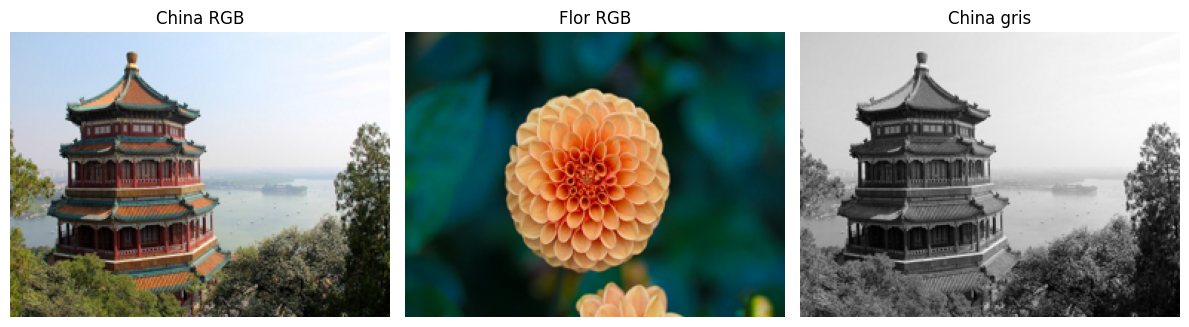

RGB: (192, 256, 3) uint8 | Gris: (192, 256) uint8


In [11]:
imagenes = {}
for nombre in ['china.jpg', 'flower.jpg']:
    imagenes[nombre] = np.asarray(Image.fromarray(load_sample_image(nombre)).resize((256, 192)))
img = imagenes['china.jpg']
gray = util.img_as_ubyte(color.rgb2gray(img))
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, im, title in zip(axes, [img, imagenes['flower.jpg'], gray], ['China RGB', 'Flor RGB', 'China gris']):
    ax.imshow(im, cmap='gray'); ax.set_title(title); ax.axis('off')
plt.tight_layout(); plt.show()
print('RGB:', img.shape, img.dtype, '| Gris:', gray.shape, gray.dtype)

### 3.2 Histogramas de color
Calculamos 8 bins por canal y normalizamos **cada canal** para que sume 1. Concatenamos R, G y B: el vector tiene 24 características y su suma total es 3.

$$\hat h_b=\frac{h_b}{\sum_j h_j}$$

`np.histogram` cuenta píxeles por intervalo; usamos el mismo rango [0, 256] para todas las imágenes.

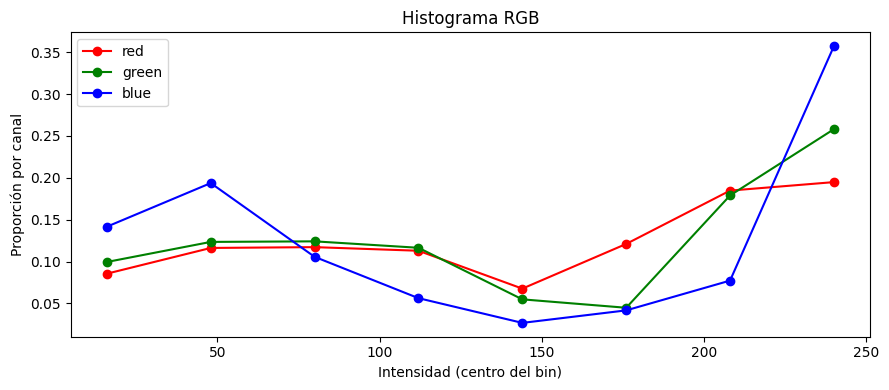

Dimensión: (24,) | Suma por canal: [1. 1. 1.]


In [12]:
def hist_color(imagen, bins=8):
    histogramas = []
    for canal in range(3):
        h, _ = np.histogram(imagen[:, :, canal], bins=bins, range=(0, 256))
        histogramas.append(h / h.sum())
    return np.concatenate(histogramas)

h_color = hist_color(img)
centros = np.arange(8) * 32 + 16
fig, ax = plt.subplots()
for c, nombre in enumerate(['red', 'green', 'blue']):
    ax.plot(centros, h_color[c*8:(c+1)*8], marker='o', color=nombre, label=nombre)
ax.set(xlabel='Intensidad (centro del bin)', ylabel='Proporción por canal', title='Histograma RGB')
ax.legend(); plt.tight_layout(); plt.show()
print('Dimensión:', h_color.shape, '| Suma por canal:', h_color.reshape(3, 8).sum(axis=1))

### 3.3 ¿Qué información se pierde?
Reordenamos píxeles completos, conservando sus tres canales. La imagen cambia, pero sus histogramas globales son idénticos.

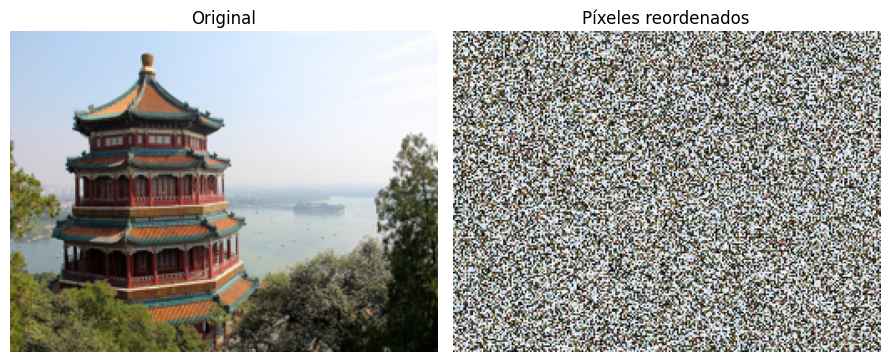

¿Histogramas iguales? True


In [13]:
pixeles = img.reshape(-1, 3)
img_mezclada = pixeles[rng.permutation(len(pixeles))].reshape(img.shape)
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for ax, im, title in zip(axes, [img, img_mezclada], ['Original', 'Píxeles reordenados']):
    ax.imshow(im); ax.set_title(title); ax.axis('off')
plt.tight_layout(); plt.show()
print('¿Histogramas iguales?', np.allclose(hist_color(img), hist_color(img_mezclada)))

### 3.4 LBP paso a paso: una vecindad
Comparamos cada vecino con el centro. Para este ejemplo manual recorremos desde arriba a la izquierda en sentido horario, asignando pesos $2^0,\ldots,2^7$.

$$\mathrm{LBP}=\sum_{p=0}^{7}\mathbb{1}[g_p\geq g_c]2^p$$

La convención de recorrido de una biblioteca puede ser diferente; también puede usar vecinos circulares interpolados. Por ello este ejemplo explica el cálculo sin exigir el mismo código que una biblioteca.

In [14]:
parche = np.array([[12, 8, 6], [11, 10, 9], [14, 13, 7]])
vecinos = parche[[0, 0, 0, 1, 2, 2, 2, 1], [0, 1, 2, 2, 2, 1, 0, 0]]
bits = (vecinos >= parche[1, 1]).astype(int)
pesos = 2 ** np.arange(8)
display(pd.DataFrame({'vecino': vecinos, 'bit': bits, 'peso': pesos, 'contribución': bits * pesos}))
print('Código LBP:', int(np.sum(bits * pesos)))

,vecino,bit,peso,contribución
0,12,1,1,1
1,8,0,2,0
2,6,0,4,0
3,9,0,8,0
4,7,0,16,0
5,13,1,32,32
6,14,1,64,64
7,11,1,128,128


Código LBP: 225


### 3.5 Mapa LBP e histograma de textura
`local_binary_pattern` aplica LBP a la imagen en escala de grises. Usamos `method='default'`, 8 vecinos y radio 1: hay 256 códigos posibles.

Excluimos un píxel de borde del histograma para evitar que domine el tratamiento del exterior. El mapa conserva posición; su histograma global la pierde.

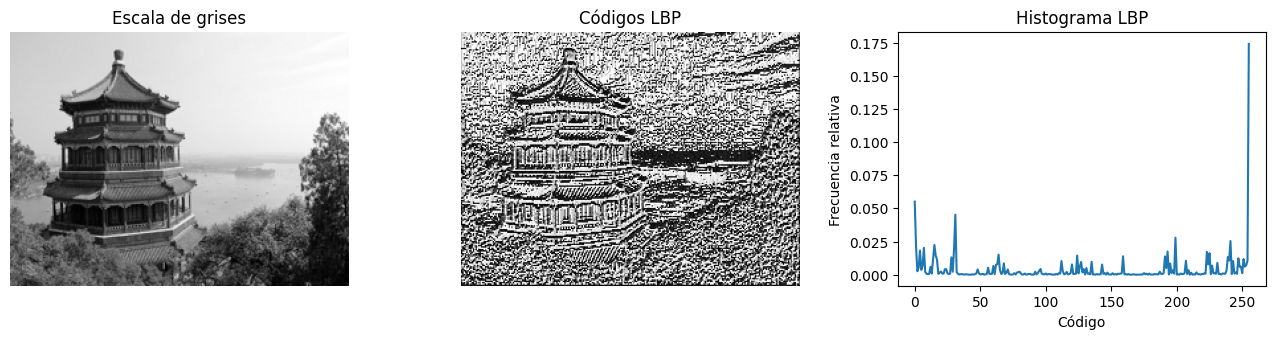

Vector LBP: (256,) | Suma: 1.0


In [15]:
P, R = 8, 1
lbp = feature.local_binary_pattern(gray, P=P, R=R, method='default')
def hist_lbp(imagen_gris):
    mapa = feature.local_binary_pattern(imagen_gris, P=8, R=1, method='default')
    h = np.bincount(mapa[1:-1, 1:-1].astype(int).ravel(), minlength=256)
    return h / h.sum()
h_lbp = hist_lbp(gray)
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
axes[0].imshow(gray, cmap='gray'); axes[0].set_title('Escala de grises'); axes[0].axis('off')
axes[1].imshow(lbp, cmap='gray', vmin=0, vmax=255); axes[1].set_title('Códigos LBP'); axes[1].axis('off')
axes[2].plot(np.arange(256), h_lbp); axes[2].set(xlabel='Código', ylabel='Frecuencia relativa', title='Histograma LBP')
plt.tight_layout(); plt.show()
print('Vector LBP:', h_lbp.shape, '| Suma:', h_lbp.sum())

## 4. Audio
### 4.1 Señales conocidas
Generamos un tono de 440 Hz, un barrido de 300 a 2500 Hz y una mezcla de ambos, con 16000 muestras por segundo durante 2 segundos. El barrido permite observar una frecuencia cambiante.

`Audio` permite escuchar la mezcla. El volumen de reproducción no representa una medición física calibrada.

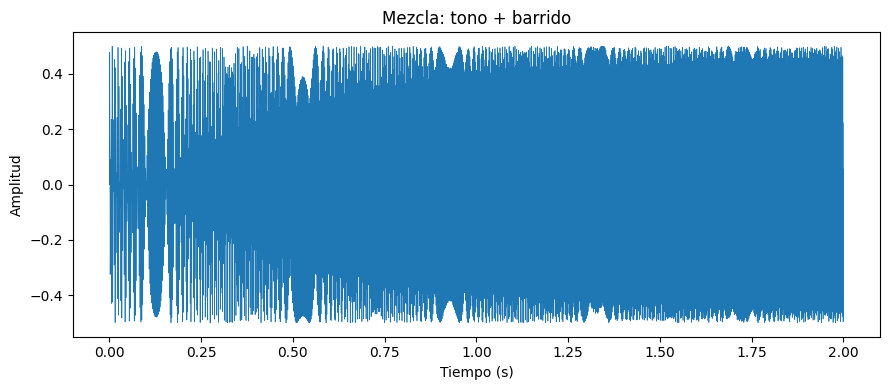

Muestras: 32000 | Duración: 2.0 s


In [16]:
sr = 16000
duracion = 2.0
t = np.arange(int(sr * duracion)) / sr
tono = 0.5 * np.sin(2 * np.pi * 440 * t)
f0, f1 = 300, 2500
pendiente = (f1 - f0) / duracion
barrido = 0.5 * np.sin(2 * np.pi * (f0*t + 0.5*pendiente*t**2))
audio = 0.5 * tono + 0.5 * barrido
plt.plot(t, audio, linewidth=.5)
plt.xlabel('Tiempo (s)'); plt.ylabel('Amplitud'); plt.title('Mezcla: tono + barrido')
plt.tight_layout(); plt.show()
display(Audio(audio, rate=sr))
print('Muestras:', audio.size, '| Duración:', audio.size/sr, 's')

### 4.2 Ventanas y STFT
Usamos ventanas de 400 muestras (25 ms), salto de 160 (10 ms) y FFT de 400 puntos. `center=False` evita añadir relleno en los extremos.

`librosa.stft` produce una matriz compleja **frecuencias × ventanas**. Su módulo al cuadrado es un espectrograma de potencia (sin calibración como densidad espectral).

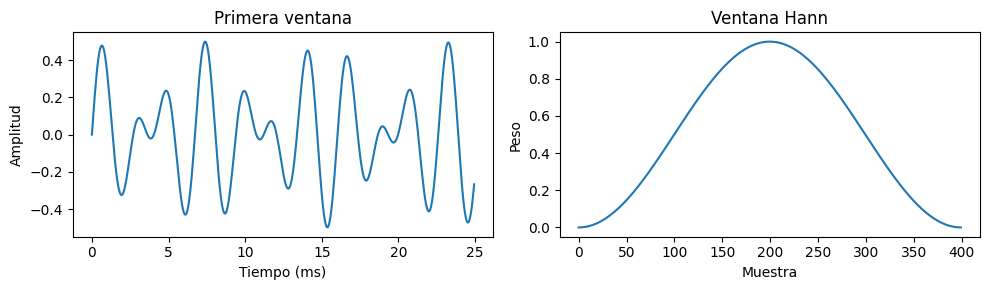

STFT (frecuencias, ventanas): (201, 198)
Salto temporal: 0.01 s | Separación de bins: 40.0 Hz


In [18]:
L, H = 400, 160
ventana = np.hanning(L)
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].plot(np.arange(L)/sr*1000, audio[:L]); axes[0].set(title='Primera ventana', xlabel='Tiempo (ms)', ylabel='Amplitud')
axes[1].plot(ventana); axes[1].set(title='Ventana Hann', xlabel='Muestra', ylabel='Peso')
plt.tight_layout(); plt.show()
# Hann periódica de la biblioteca; np.hanning arriba ilustra su forma.
D = librosa.stft(audio, n_fft=L, hop_length=H, win_length=L, window='hann', center=False)
potencia = np.abs(D)**2
print('STFT (frecuencias, ventanas):', D.shape)
print('Salto temporal:', H/sr, 's | Separación de bins:', sr/L, 'Hz')

### 4.3 Espectrograma en decibeles
Mostramos potencia relativa al máximo:

$$S_{dB}=10\log_{10}\left(\frac{S}{S_{max}}\right)$$

La biblioteca aplica un piso numérico y limita el rango mostrado a 80 dB. Deben observarse una línea cerca de 440 Hz y otra ascendente. La potencia descarta la fase de la STFT.

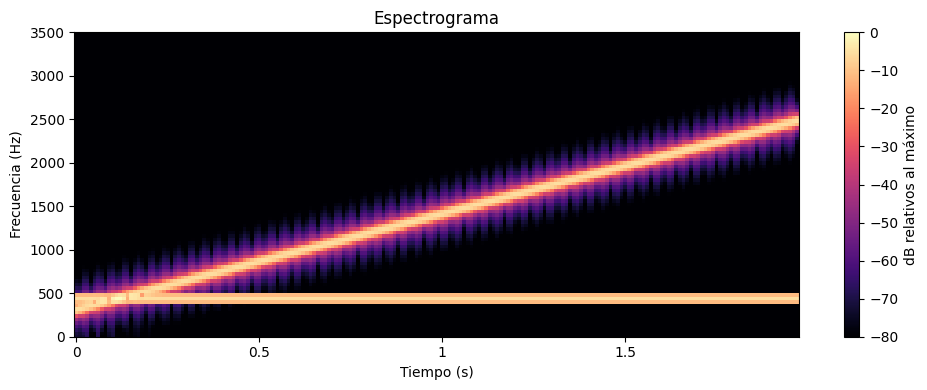

In [19]:
potencia_db = librosa.power_to_db(potencia, ref=np.max, top_db=80)
fig, ax = plt.subplots(figsize=(10, 4))
im = librosa.display.specshow(potencia_db, sr=sr, hop_length=H, x_axis='time', y_axis='linear', ax=ax)
ax.set_ylim(0, 3500); ax.set(title='Espectrograma', xlabel='Tiempo (s)', ylabel='Frecuencia (Hz)')
fig.colorbar(im, ax=ax, label='dB relativos al máximo')
plt.tight_layout(); plt.show()

### 4.4 Filtros Mel y representación log-Mel
Usamos 40 filtros entre 0 y 8000 Hz. `htk=True` selecciona la conversión Mel de la presentación. `norm=None` conserva filtros de altura unitaria, sin normalización por área.

Multiplicamos el banco de filtros por el espectrograma para obtener energía por banda. Luego aplicamos el logaritmo mediante decibeles.

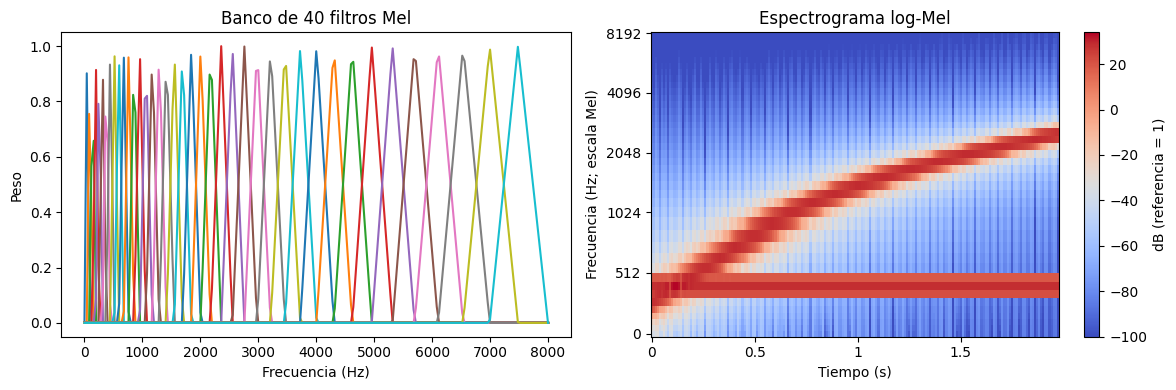

Log-Mel (bandas, ventanas): (40, 198)


In [20]:
n_mels = 40
filtros_mel = librosa.filters.mel(sr=sr, n_fft=L, n_mels=n_mels,
                                fmin=0, fmax=sr/2, htk=True, norm=None)
energia_mel = filtros_mel @ potencia
log_mel = librosa.power_to_db(energia_mel, ref=1.0, top_db=None)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
frecuencias = librosa.fft_frequencies(sr=sr, n_fft=L)
axes[0].plot(frecuencias, filtros_mel.T)
axes[0].set(title='Banco de 40 filtros Mel', xlabel='Frecuencia (Hz)', ylabel='Peso')
im = librosa.display.specshow(log_mel, sr=sr, hop_length=H, x_axis='time',
                              y_axis='mel', htk=True, fmin=0, fmax=sr/2, ax=axes[1])
axes[1].set(title='Espectrograma log-Mel', xlabel='Tiempo (s)', ylabel='Frecuencia (Hz; escala Mel)')
fig.colorbar(im, ax=axes[1], label='dB (referencia = 1)')
plt.tight_layout(); plt.show()
print('Log-Mel (bandas, ventanas):', log_mel.shape)

### 4.5 MFCC: DCT y selección de coeficientes
Aplicamos DCT tipo II al log-Mel y conservamos los primeros 13 coeficientes, incluido el cero. Usar decibeles en lugar de logaritmo natural introduce un factor de escala; es la convención empleada aquí y por `librosa`.

La DCT se aplica **entre bandas**, no entre ventanas. La matriz MFCC conserva su secuencia temporal. Comparamos el cálculo explícito con `librosa.feature.mfcc`.

¿DCT y librosa coinciden? True
MFCC (coeficientes, ventanas): (13, 198)


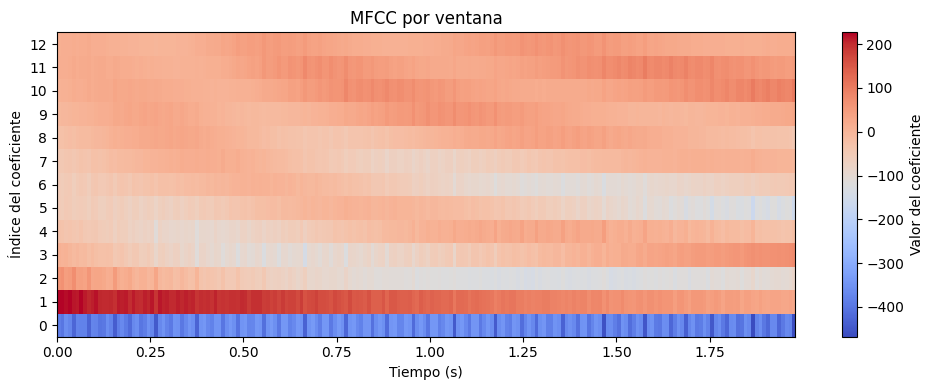

In [21]:
n_mfcc = 13
mfcc = dct(log_mel, type=2, axis=0, norm='ortho')[:n_mfcc]
mfcc_librosa = librosa.feature.mfcc(S=log_mel, n_mfcc=n_mfcc, dct_type=2, norm='ortho')
print('¿DCT y librosa coinciden?', np.allclose(mfcc, mfcc_librosa))
print('MFCC (coeficientes, ventanas):', mfcc.shape)
fig, ax = plt.subplots(figsize=(10, 4))
im = ax.imshow(mfcc, origin='lower', aspect='auto',
               extent=[0, mfcc.shape[1]*H/sr, -0.5, n_mfcc-0.5], cmap='coolwarm')
ax.set(xlabel='Tiempo (s)', ylabel='Índice del coeficiente', title='MFCC por ventana', yticks=np.arange(n_mfcc))
fig.colorbar(im, ax=ax, label='Valor del coeficiente')
plt.tight_layout(); plt.show()

### 4.6 Un vector por grabación
Calculamos media y desviación estándar de cada coeficiente a lo largo del tiempo: 13 + 13 = 26 características.

**Aclaración sobre la presentación:** los MFCC por ventana conservan el orden temporal; es esta agregación la que lo pierde. Reordenar las columnas de la matriz MFCC produce el mismo resumen.

In [22]:
def resumir_mfcc(coeficientes):
    return np.r_[coeficientes.mean(axis=1), coeficientes.std(axis=1)]

vector_audio = resumir_mfcc(mfcc)
columnas_audio = [f'mfcc_{i}_media' for i in range(n_mfcc)] + [f'mfcc_{i}_std' for i in range(n_mfcc)]
display(pd.DataFrame([vector_audio], columns=columnas_audio).round(2))
reordenados = mfcc[:, rng.permutation(mfcc.shape[1])]
print('Dimensión:', vector_audio.shape)
print('¿Mismo resumen al reordenar ventanas?', np.allclose(vector_audio, resumir_mfcc(reordenados)))

,mfcc_0_media,mfcc_1_media,mfcc_2_media,mfcc_3_media,mfcc_4_media,mfcc_5_media,mfcc_6_media,mfcc_7_media,mfcc_8_media,mfcc_9_media,...,mfcc_3_std,mfcc_4_std,mfcc_5_std,mfcc_6_std,mfcc_7_std,mfcc_8_std,mfcc_9_std,mfcc_10_std,mfcc_11_std,mfcc_12_std
0,-374.2,129.09,-81.7,-32.45,-23.74,-56.76,-57.01,-22.91,1.08,19.29,...,56.34,39.85,43.07,37.97,30.38,24.87,21.82,25.25,24.29,18.21


Dimensión: (26,)
¿Mismo resumen al reordenar ventanas? True


### 4.7 Matriz de características de varias grabaciones
Repetimos **la misma configuración** para tres señales. Cada fila representa una grabación y cada columna una característica. Esto ilustra la extracción; tres señales no bastan para evaluar un clasificador.

In [23]:
def extraer_audio(senal):
    espectro = np.abs(librosa.stft(senal, n_fft=L, hop_length=H, window='hann', center=False))**2
    mel_db = librosa.power_to_db(filtros_mel @ espectro, ref=1.0, top_db=None)
    coef = librosa.feature.mfcc(S=mel_db, n_mfcc=n_mfcc, dct_type=2, norm='ortho')
    return resumir_mfcc(coef)

X_audio = pd.DataFrame([extraer_audio(s) for s in [tono, barrido, audio]],
                       index=['tono', 'barrido', 'mezcla'], columns=columnas_audio)
display(X_audio.round(2))
print('Forma:', X_audio.shape)

,mfcc_0_media,mfcc_1_media,mfcc_2_media,mfcc_3_media,mfcc_4_media,mfcc_5_media,mfcc_6_media,mfcc_7_media,mfcc_8_media,mfcc_9_media,...,mfcc_3_std,mfcc_4_std,mfcc_5_std,mfcc_6_std,mfcc_7_std,mfcc_8_std,mfcc_9_std,mfcc_10_std,mfcc_11_std,mfcc_12_std
tono,-571.26,71.84,32.94,-16.44,-59.11,-80.62,-74.38,-43.73,-0.36,40.23,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
barrido,-377.09,89.03,-105.94,-20.01,10.10,-5.88,-12.23,5.44,1.50,-4.18,...,57.38,51.20,42.60,32.68,31.64,25.52,23.16,20.88,17.75,17.00
mezcla,-374.20,129.09,-81.70,-32.45,-23.74,-56.76,-57.01,-22.91,1.08,19.29,...,56.34,39.85,43.07,37.97,30.38,24.87,21.82,25.25,24.29,18.21


Forma: (3, 26)


## 5. Integración y buenas prácticas
### 5.1 Concatenar descriptores de la misma observación
Combinamos color y textura para cada fotografía: 24 + 256 = 280 características. Ambos bloques se calculan sobre **la misma imagen**.

No concatenamos filas de modalidades distintas sin una correspondencia entre observaciones. En un estudio real, los escaladores se ajustan solo con entrenamiento; la división por objeto o sujeto se realiza antes de generar variantes.

In [24]:
filas = []
for im in imagenes.values():
    im_gray = util.img_as_ubyte(color.rgb2gray(im))
    filas.append(np.r_[hist_color(im), hist_lbp(im_gray)])
X_imagen = np.vstack(filas)
print('Matriz combinada (imágenes, características):', X_imagen.shape)

# Cada fila conserva el mismo orden: primero RGB, después LBP.
columnas_img = [f'{canal}_bin_{b}' for canal in ['R', 'G', 'B'] for b in range(8)]
columnas_img += [f'lbp_{b}' for b in range(256)]
tabla_imagen = pd.DataFrame(X_imagen, index=list(imagenes), columns=columnas_img)
display(tabla_imagen.iloc[:, :8].round(3))

Matriz combinada (imágenes, características): (2, 280)


,R_bin_0,R_bin_1,R_bin_2,R_bin_3,R_bin_4,R_bin_5,R_bin_6,R_bin_7
china.jpg,0.085,0.116,0.117,0.113,0.068,0.121,0.185,0.195
flower.jpg,0.725,0.023,0.006,0.007,0.012,0.036,0.107,0.085


### 5.2 Resumen de salidas
Los descriptores tienen tamaños distintos. Una dimensión mayor no implica automáticamente una representación mejor. La estandarización por variable tampoco garantiza equilibrar el peso de bloques de distinto tamaño.

In [27]:
display(pd.DataFrame({
    'Representación': ['BoW', 'Unigramas + bigramas', 'TF-IDF', 'Color RGB', 'LBP', 'Espectrograma', 'MFCC', 'Resumen MFCC'],
    'Forma en este ejemplo': [str(x.shape) for x in [X_bow, X_ngramas, X_tfidf, h_color, h_lbp, potencia, mfcc, vector_audio]],
    'Unidad': ['corpus', 'corpus', 'corpus', 'imagen', 'máscara', 'grabación', 'grabación', 'grabación']
}))

,Representación,Forma en este ejemplo,Unidad
0,BoW,"(7, 10)",corpus
1,Unigramas + bigramas,"(7, 25)",corpus
2,TF-IDF,"(7, 10)",corpus
3,Color RGB,"(24,)",imagen
4,LBP,"(256,)",máscara
5,Espectrograma,"(201, 198)",grabación
6,MFCC,"(13, 198)",grabación
7,Resumen MFCC,"(26,)",grabación


### 5.3 Ejercicios breves
1. Cambia `ngram_range` a `(1, 3)`. ¿Cuántas características aparecen? Identifica un trigrama con negación.
2. Cambia los bins de color a 16. ¿Cuánto crece el vector? ¿Se recupera la ubicación de los píxeles?
3. Cambia el radio de LBP a 2. Compara el mapa e histograma usando parámetros consistentes y excluyendo el borde adecuado.
4. Cambia la ventana de audio a 800 muestras y recalcula también el banco Mel. ¿Cómo cambia el detalle temporal y frecuencial?
5. Conserva 20 MFCC. ¿Cuántas características tiene el resumen por grabación?

### Conclusiones
- BoW, n-gramas y TF-IDF permiten representar documentos en un espacio común.
- Color y textura describen propiedades diferentes.
- El espectrograma y los MFCC conservan estructura temporal por ventanas.
- La agregación facilita obtener vectores de tamaño fijo, pero pierde detalle.

### Declaración de uso de IA generativa

Este notebook fue elaborado con apoyo de ChatGPT 6 (OpenAI) para estructurar el contenido a partir de las diapositivas de la sesión y redactar el texto explicativo. El diseño pedagógico, la selección de temas y la revisión final son responsabilidad del titular del curso.